Analysis of the aggregated cell survival data
- With classic LQ fit
- With unweighted Rorvik

In [14]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from sklearn.metrics import r2_score

CHANGE THESE: the relevant folder and file paths

In [22]:
#enter list of paths to results folders here
results_folders = [r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Analysis Corrected results 16 Oct", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Analysis Corrected results 30 Oct", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Analysis Corrected results 18 Nov", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Analysis Results 4-2"] 

#enter list of multiplicity file paths here
multi_x = [r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity X-ray 16-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity X-ray 30-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity X-ray 18-11.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Irradiations 4-2\Multiplicity X-ray 4-2.xlsx"]
multi_p = [r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity proton 16-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity proton 30-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity proton 18-11.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Irradiations 4-2\Multiplicity protons 4-2.xlsx"]


Loading and importing data.

In [16]:
def write_fractions_dic(path):
    data = pd.read_excel(path)
    
    total = np.array(data['Total'])[-1]

    fractions_dic = {}

    for column in data.items():
        if column[0] != 'Sample' and column[0] != 'Total': #ignore first and last column
            size = column[0]
            count = np.array(column[1])[-1]

            frac = count/total

            fractions_dic[size] = frac

    return fractions_dic

In [17]:
def cfu_survival_func(s, dic, SF):
    sum = 0
    for key, frac in dic.items():
        power = np.power((1-s),int(key))
        sum += frac*(1-power)
    
    #subtract the SF to use root
    sum -= SF
    return sum

In [18]:
def Parse_data(input, exp, fractions_dic):
    #Split colony counting data into cell survival for each sample
    #The survival is calculated for each triplicate separately and normalised to control
    #Also write LET to output for Rorvik calculations

    #inputs:
    #input = dataframe with the dose, plated cells and count of each triplicate for each sample, Format [Dose Plated Count1 Count2 Count3]

    #outputs:
    #output = dataframe with survival per triplicate and LET, Format [Dose LET Survival]

    def write_LET(rad_type):
        if rad_type == 'X':
            return 2.02
        if rad_type == 'Proton L':
            return 1.3
        if rad_type == 'Proton H':
            return 16.0

    triplicates_control = ["Count_1", "Count_2", "Count_3","Count_4", "Count_5", "Count_6"]

    #Isolate controls, calculate control survival for normalising
    control_data = input[input['Dose'] == 0]
    control_survival = control_data[triplicates_control].mean(axis=1)/control_data['Plated']

    #Write data to output with dose and survival
    output = pd.DataFrame(columns=['Dose', 'LET', 'Survival'])

    #Loop through rows of input to process data and write to output.
    #Each triplicate is processed separately
    for row in input.itertuples():
        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_1/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_2/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_3/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        if row.Dose == 0:
            newrow = {}
            newrow['Dose'] = row.Dose
            survival = (row.Count_4/row.Plated)/control_survival
            newrow['SF'] = float(survival.iloc[0])
            newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
            newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
            newrow['Experiment'] = exp
            output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

            newrow = {}
            newrow['Dose'] = row.Dose
            survival = (row.Count_5/row.Plated)/control_survival
            newrow['SF'] = float(survival.iloc[0])
            newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
            newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
            newrow['Experiment'] = exp
            output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

            newrow = {}
            newrow['Dose'] = row.Dose
            survival = (row.Count_6/row.Plated)/control_survival
            newrow['SF'] = float(survival.iloc[0])
            newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
            newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
            newrow['Experiment'] = exp
            output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

    return output

In [23]:
#Load and process data

#Loop through folders to extract all excels and write to dataframes
X = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment'])
PL = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment'])
PH = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment'])

for i in range(len(results_folders)):
    folder = results_folders[i]
    multiplicity_x = write_fractions_dic(multi_x[i])
    multiplicity_p = write_fractions_dic(multi_p[i])
    for file in os.listdir(folder):
        if os.path.splitext(os.path.join(folder, file))[-1] == '.xlsx':
            #Read in if it's an excel file
            df = pd.read_excel(os.path.join(folder, file), index_col=None)

            #Check the radiation type and write to correct dataframe
            if df.tail(1)['Rad'].item() == 'X':
                data = Parse_data(df, i+1, multiplicity_x)
                #Correct X-ray dose
                data['Dose'] = 0.85*data['Dose'] 
                X = pd.concat([X, data])   
            if df.tail(1)['Rad'].item() == 'Proton L':
                data = Parse_data(df, i+1, multiplicity_p)
                data['Dose'] = data['Dose']
                PL = pd.concat([PL, data])
            if df.tail(1)['Rad'].item() == 'Proton H':
                PH = pd.concat([PH, Parse_data(df, i+1, multiplicity_p)])



C:\Users\bhaan\AppData\Local\Temp\ipykernel_22508\297187906.py:36: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
C:\Users\bhaan\AppData\Local\Temp\ipykernel_22508\297187906.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_22508\297187906.py:64: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow

# Perform LQ fit on data

In [29]:
def Process_data(input):
    #Process [Dose Survival] data per sample into a mean and std per triplicate

    #inputs
    #df = dataframe [Dose Survival Experiment] per sample as outputted by the cell loading the data

    #output
    #df_means = dataframe ['Dose' 'Mean Survival' 'Experiment] per triplicate
    #df_stds = standard deviation of log of survival per triplicate

    #copy the input for processing
    df = input.copy()
    dose_levels = np.unique(df['Dose'])

    df_means_total = pd.DataFrame(columns=['Dose', 'Mean Survival', 'STD', 'Experiment'])

    for exp in np.unique(df['Experiment']):
        data = df[df['Experiment']==exp]

        #Process into mean and std per triplicate
        df_means = pd.DataFrame(columns=['Dose', 'Mean Survival', 'STD', 'Experiment'])

        for i in range(len(dose_levels)):
            dose = dose_levels[i]
            
            #Select triplicate
            trip = data[data['Dose']==dose]
            newrow = {}

            #Write dose
            newrow['Dose'] = dose
            newrow['Experiment'] = trip['Experiment'].iloc[0]

            #Calculate mean, ignoring any NaN values
            newrow['Mean Survival'] = np.nanmean(np.array(trip['Survival']))
            #Write standard dev
            newrow['STD'] = np.nanstd(np.array(trip['Survival']))
            df_means = pd.concat([df_means, pd.DataFrame([newrow])])


        #Re-normalise with multiplicities
        df_means['Mean Survival'] = df_means['Mean Survival']/df_means['Mean Survival'].iloc[0] 

        df_means_total = pd.concat([df_means_total, df_means])   

    return df_means_total 

In [25]:
def Perform_LQ_fit(sample):
    #Generate LQ fit

    #inputs:
    #sample = dataframe as ['Dose' 'Mean Survival'] for all triplicates, as outputted by 'Process_data'

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations

    def Function(d, a, b):
        return np.exp(-(a*d + b*(np.square(d))))

    x = np.array(sample['Dose'], dtype='float')
    y = np.array(sample['Mean Survival'], dtype = 'float')

    p0 = (0.1, 0.1)

    popt, pcov = curve_fit(Function, x, y, p0=p0, bounds=(0,1))
    
    return popt

In [26]:
def LQ_func(d, a, b):
        return np.exp(-(a*d + b*(np.square(d))))

In [30]:
#Process data into means and standard devs for all
X_means = Process_data(X) 
PL_means = Process_data(PL)
PH_means = Process_data(PH)

#Dose uncertainties
#X-ray dose uncertainty obtained from the experiments with Michel as described in my notebook on 2/12/2025
X_dose_err = pd.DataFrame({'Dose':X_means['Dose'], 'Err': 0.071*X_means['Dose'], 'Exp': X_means['Experiment']})
#Proton dose uncertainties obtained from dosimetry, as described in dosimetry final
PL_dose_err = pd.DataFrame({'Dose':PL_means['Dose'], 'Err': 0.029*PL_means['Dose'], 'Exp': PL_means['Experiment']})
PH_dose_err = pd.DataFrame({'Dose':PH_means['Dose'], 'Err': 0.038*PH_means['Dose'], 'Exp': PH_means['Experiment']})


C:\Users\bhaan\AppData\Local\Temp\ipykernel_22508\1333535518.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_means = pd.concat([df_means, pd.DataFrame([newrow])])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_22508\1333535518.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_means_total = pd.concat([df_means_total, df_means])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_22508\1333535518.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is depre

In [32]:
#LQ fit X-rays

params_x = Perform_LQ_fit(X_means)

true = X_means['Mean Survival']
pred = LQ_func(np.array(X_means['Dose'], dtype=float), params_x[0], params_x[1])
r2_x = r2_score(np.log10(true), np.log10(pred))


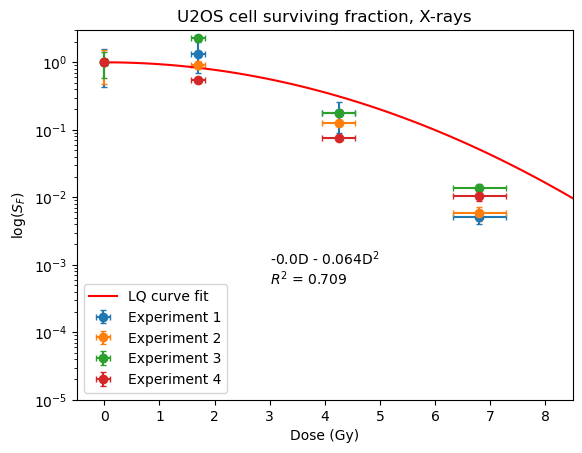

In [35]:
#Plot X-rays
#plot per experiment
for i in range(len(np.unique(np.array(X_means['Experiment'])))):
    exp = np.unique(np.array(X_means['Experiment']))[i]
    data = X_means[X_means['Experiment']==exp]
    error = np.array(data['STD'])
    dose_error = X_dose_err[X_dose_err['Exp']==exp]
    plt.errorbar(data['Dose'], data['Mean Survival'], yerr=error, xerr=dose_error['Err'], fmt='o', capsize=2, label=f'Experiment {int(exp)}')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, X-rays')
plt.text(3, 0.001, f"-{round(params_x[0],3)}D - {round(params_x[1],3)}D$^2$")
plt.text(3, 0.0005, f"$R^2$ = {round(r2_x, 3)}")
plt.xlim([-0.5, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

In [36]:
#LQ fit proton low

params_pl = Perform_LQ_fit(PL_means)

true = PL_means['Mean Survival']
pred = LQ_func(np.array(PL_means['Dose'], dtype=float), params_pl[0], params_pl[1])

r2_pl = r2_score(np.log10(true), np.log10(pred))

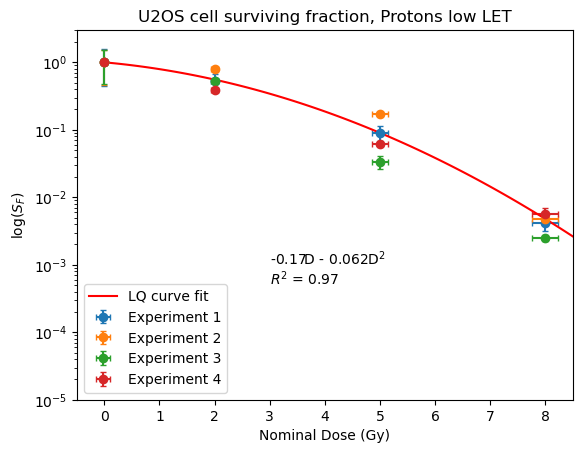

In [37]:
#Plot protons low
for i in range(len(np.unique(np.array(PL_means['Experiment'])))):
    exp = np.unique(np.array(PL_means['Experiment']))[i]
    data = PL_means[PL_means['Experiment']==exp]
    error = np.array(data['STD'])
    dose_error = PL_dose_err[PL_dose_err['Exp']==exp]
    plt.errorbar(data['Dose'], data['Mean Survival'], yerr=error, xerr=dose_error['Err'], fmt='o', capsize=2, label=f'Experiment {int(exp)}')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_pl[0], params_pl[1]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, Protons low LET')
plt.text(3, 0.001, f"-{round(params_pl[0],3)}D - {round(params_pl[1],3)}D$^2$")
plt.text(3, 0.0005, f"$R^2$ = {round(r2_pl, 3)}")
plt.xlim([-0.5, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

In [38]:
#LQ fit proton high

params_ph = Perform_LQ_fit(PH_means)

true = PH_means['Mean Survival']
pred = LQ_func(np.array(PH_means['Dose'], dtype=float), params_ph[0], params_ph[1])

r2_ph = r2_score(np.log10(true), np.log10(pred)) 

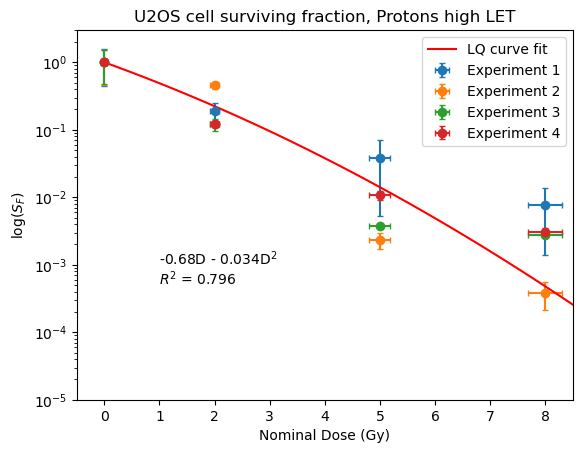

In [39]:
#Plot Protons High
for i in range(len(np.unique(np.array(PH_means['Experiment'])))):
    exp = np.unique(np.array(PH_means['Experiment']))[i]
    data = PH_means[PH_means['Experiment']==exp]
    error = np.array(data['STD'])
    dose_error = PH_dose_err[PH_dose_err['Exp']== exp]
    plt.errorbar(data['Dose'], data['Mean Survival'], yerr=error, xerr=dose_error['Err'], fmt='o', capsize=2, label=f'Experiment {int(exp)}')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_ph[0], params_ph[1]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, Protons high LET')
plt.text(1, 0.001, f"-{round(params_ph[0],3)}D - {round(params_ph[1],3)}D$^2$")
plt.text(1, 0.0005, f"$R^2$ = {round(r2_ph, 3)}")
plt.xlim([-0.5, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

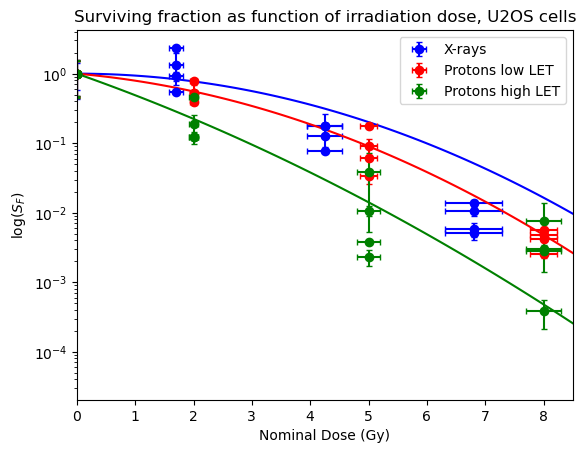

In [41]:
#Plot them all together
plt.errorbar(X_means['Dose'], X_means['Mean Survival'], yerr=X_means['STD'], xerr=X_dose_err['Err'], label='X-rays', color='b', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color='b')

plt.errorbar(PL_means['Dose'], PL_means['Mean Survival'], yerr=PL_means['STD'], xerr=PL_dose_err['Err'], label='Protons low LET', color='r', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_pl[0], params_pl[1]), color='r')

plt.errorbar(PH_means['Dose'], PH_means['Mean Survival'], yerr=PH_means['STD'], xerr=PH_dose_err['Err'], label='Protons high LET', color='g', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_ph[0], params_ph[1]), color='g')

plt.title('Surviving fraction as function of irradiation dose, U2OS cells')
plt.xlim([0, 8.5])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

# Rørvik fit

In [42]:
def Rorvik_fit(sample):
    #input
    #sample = pandas dataframe with dose, let, survival for given radiation type

    #output = fit data

    #Generate a design matrix of the format 'dose, LET*dose, dose^2, log survival
    dose = np.array(sample['Dose'], dtype='float')
    let = np.array(sample['LET'], dtype = 'float')
    X= np.column_stack((dose, dose*let, np.square(dose)))
    y = np.log(np.array(sample['Survival'], dtype = 'float'))
    
    model = sm.OLS(y, X)
    results = model.fit()
    print(results.summary())

    return results.params


In [43]:
#Take copies
X_rorvik = X.copy()
PL_rorvik = PL.copy()
PH_rorvik = PH.copy()

#Remove any zero survivals
X_rorvik = X_rorvik[X_rorvik['SF']!=0]
PL_rorvik = PL_rorvik[PL_rorvik['SF']!=0]
PH_rorvik = PH_rorvik[PH_rorvik['SF']!=0]

#Remove NaN
X_rorvik.dropna(inplace=True, subset=['SF'])
PL_rorvik.dropna(inplace=True, subset=['SF'])
PH_rorvik.dropna(inplace=True, subset=['SF'])

#Aggregate data back into one dataframe
total_data = pd.concat([X_rorvik, PL_rorvik, PH_rorvik])

#Fit curve
params = Rorvik_fit(total_data)

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.945
Model:                            OLS   Adj. R-squared (uncentered):              0.944
Method:                 Least Squares   F-statistic:                              847.4
Date:                Thu, 19 Feb 2026   Prob (F-statistic):                    1.57e-92
Time:                        13:21:29   Log-Likelihood:                         -179.73
No. Observations:                 150   AIC:                                      365.5
Df Residuals:                     147   BIC:                                      374.5
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

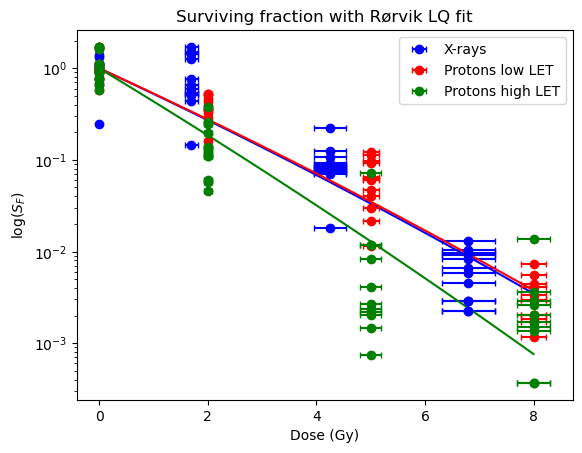

In [45]:
#Plot data
d = np.linspace(0,8,100)
let = X_rorvik.iloc[0]['LET']
y = np.exp(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.errorbar(X_rorvik['Dose'], X_rorvik['Survival'], xerr=0.071*X_rorvik['Dose'], label='X-rays', color='blue', fmt='o', capsize=2)
plt.plot(d, y, color='blue')

d = np.linspace(0,8,100)
let = PL_rorvik.iloc[0]['LET']
y = np.exp(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.errorbar(PL_rorvik['Dose'], PL_rorvik['Survival'], xerr=0.029*PL_rorvik['Dose'], label='Protons low LET', fmt='o', color='red', capsize=2)
plt.plot(d, y, color='red')

d = np.linspace(0,8,100)
let = PH_rorvik.iloc[0]['LET']
y = np.exp(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.errorbar(PH_rorvik['Dose'], PH_rorvik['Survival'], xerr=0.038*PH_rorvik['Dose'], label='Protons high LET', fmt='o', color='green', capsize=2)
plt.plot(d, y, color='green')

#Customise
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction with Rørvik LQ fit')
plt.legend()
plt.yscale('log')

Attempt to implement RBE model according to Rorvik

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_22508\4061729913.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('LET (keV/$\mu$m)')


Text(0.5, 0.92, 'RBE as function of dose and LET, Rørvik')

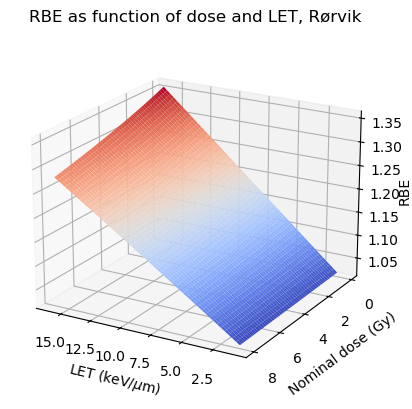

In [46]:
letvals = np.linspace(1, 16, 1000)
dosevals = np.linspace(0.1, 8, 1000)
letvals, dosevals = np.meshgrid(letvals, dosevals)

a_x = params[0]
b_x = params[2]
k = params[1]

RBEmin = 1
RBEmax = 1 + (k/a_x)*letvals
A_B = a_x/b_x

squareterm = np.square(A_B) + 4*dosevals*A_B*RBEmax + 4*np.square(dosevals)*np.square(RBEmin)
RBE = (1/(2*dosevals))*(np.sqrt(squareterm) - A_B)

fig = plt.figure()

ax1 = fig.add_subplot(1, 1, 1, projection='3d')
ax1.view_init(elev=20, azim=120, roll=0)
ax1.plot_surface(letvals, dosevals, RBE, cmap = 'coolwarm')
ax1.set_xlabel('LET (keV/$\mu$m)')
ax1.set_ylabel('Nominal dose (Gy)')
ax1.set_zlabel('RBE', rotation=90)
ax1.zaxis.labelpad=-0.8 
ax1.set_title('RBE as function of dose and LET, Rørvik')


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_22508\1626334991.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('LET (keV/$\mu$m)')


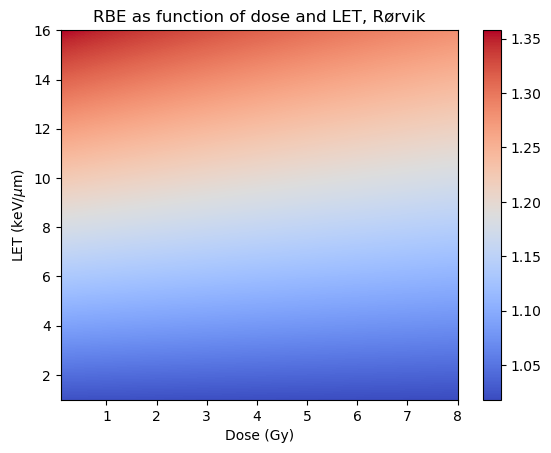

In [47]:
plt.pcolormesh(dosevals, letvals, RBE, cmap='coolwarm')
plt.ylabel('LET (keV/$\mu$m)')
plt.xlabel('Dose (Gy)')
plt.title('RBE as function of dose and LET, Rørvik')
plt.colorbar()

# Mid LET prediction from Rorvik

Text(0, 0.5, 'log($S_F$)')

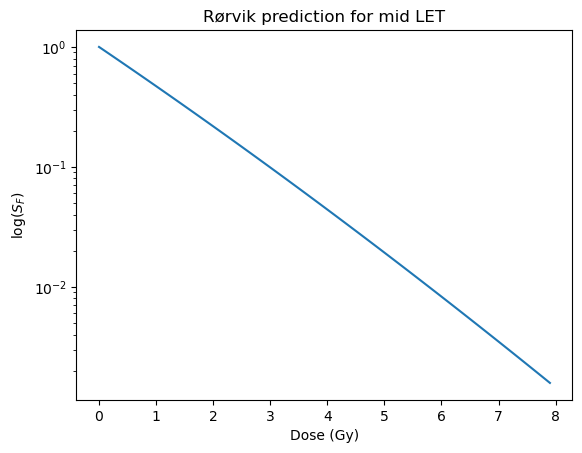

In [53]:
dosevals = np.arange(0, 8, 0.1)
mid_let = 10.1 #kev/um

pred_survival = np.exp(params[0]*dosevals + params[1]*mid_let*dosevals + params[2]*dosevals*dosevals)

plt.plot(dosevals, pred_survival)
plt.yscale('log')
plt.title('Rørvik prediction for mid LET')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')